# Freight Rate Prediction – EDA, missing data, validation and final model
Goal: predict `posted_rate` for the 12,000 loads in `validation.csv`, and for a fixed lane (Lexington → Fort Wayne) on each day of December 2025.

The reusable code lives in `src/freight.py`; this notebook walks through the same steps with explanations. `python run_pipeline.py` does everything in one command. Only numpy, pandas and matplotlib are used (no scikit-learn): the gradient boosting and ridge models are implemented in `src/freight.py`.

## 1. Load data
The validation file covers **Nov–Dec 2025**, after the last training date (Oct 31). The real test is therefore in the **future**, so we validate by time, not with a random split.

In [10]:
import os
print("Folder exists:", os.path.exists("E:/task/data"))

Folder exists: True


In [12]:
import sys; sys.path.insert(0, 'E:/task/src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import freight as fr
from pathlib import Path

# Set data directory path
data_dir = Path('E:/task/data')

# Load files individually matching your exact filenames
tr = pd.read_csv(data_dir / 'train-test.csv', parse_dates=['date'])
va = pd.read_csv(data_dir / 'validation.csv', parse_dates=['date'])
template = pd.read_csv(data_dir / 'validation-predictions-template.csv')
dec = pd.read_csv(data_dir / 'december-chart-inputs.csv')

# Continue with category mapping and printing summaries
cats = fr.make_category_map(tr, va)

print('train     :', tr.shape, tr.date.min().date(), '->', tr.date.max().date())
print('validation:', va.shape, va.date.min().date(), '->', va.date.max().date())
tr.head()

train     : (48000, 14) 2025-01-01 -> 2025-10-31
validation: (12000, 13) 2025-11-01 -> 2025-12-31


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 2. EDA

In [13]:
print(tr.describe().T.round(2).to_string())
print(); print(tr.equipment.value_counts())
tr['rpm'] = tr.posted_rate / tr.distance
print(); print('median rate per mile:'); print(tr.groupby('equipment').rpm.median().round(2))
print(); print(tr[['distance','weight','market_index','quote_signal','posted_rate']].corr().round(2))

                count                        mean                  min                  25%                  50%                  75%                  max          std
pickup_lat    48000.0                   35.647545             28.35765             31.98691             35.29479             39.41104             44.30296     4.315285
pickup_lon    48000.0                  -90.928964           -121.69849            -98.40059            -88.08915            -83.28506                -69.5    13.482431
delivery_lat  48000.0                   35.641175             28.35765             31.98691             35.29479             39.41104             44.30296     4.317199
delivery_lon  48000.0                   -90.85731           -121.69849            -98.40059            -87.52871            -83.28506                -69.5    13.476589
distance      48000.0                 1135.856654                 70.0                550.4                953.3             1645.525               3439.8   728

Distance is by far the strongest signal (correlation ≈ 0.91). Reefer is the most expensive per mile, Dry Van the cheapest. `weight`, `market_index` and `quote_signal` show almost no linear correlation on their own.

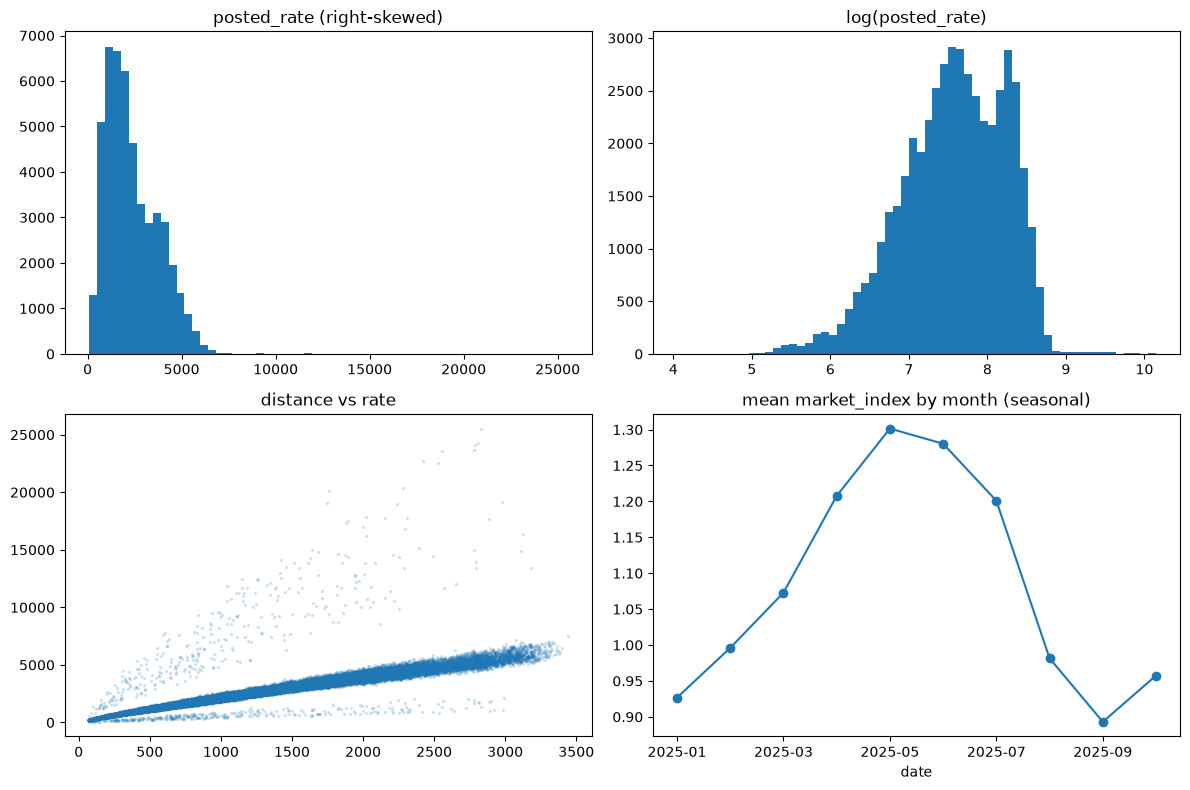

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].hist(tr.posted_rate, bins=60); ax[0,0].set_title('posted_rate (right-skewed)')
ax[0,1].hist(np.log(tr.posted_rate), bins=60); ax[0,1].set_title('log(posted_rate)')
ax[1,0].scatter(tr.distance, tr.posted_rate, s=2, alpha=.15); ax[1,0].set_title('distance vs rate')
m = tr.date.dt.to_period('M').astype(str)
tr.groupby(m).market_index.mean().plot(ax=ax[1,1], marker='o', title='mean market_index by month (seasonal)')
plt.tight_layout(); plt.show()

The target is right-skewed, so we model **log(rate)** and convert back. `market_index` is **seasonal**; that is why missing values are filled by month later.

## 3. Missing and bad data

In [15]:
print('missing  – train      :', tr[['weight','market_index']].isna().sum().to_dict())
print('missing  – validation :', va[['weight','market_index']].isna().sum().to_dict())
print('negative weight – train / validation:', (tr.weight < 0).sum(), '/', (va.weight < 0).sum())
print('other missing columns :', tr.drop(columns=['weight','market_index']).isna().sum().sum())
print('duplicate load_id     :', tr.load_id.duplicated().sum())
print('rate/mile > 10        :', (tr.rpm > 10).sum(), 'rows')
print('rate/mile < 0.5       :', (tr.rpm < 0.5).sum(), 'rows')

missing  – train      : {'weight': 300, 'market_index': 374}
missing  – validation : {'weight': 165, 'market_index': 249}
negative weight – train / validation: 292 / 145
other missing columns : 0
duplicate load_id     : 0
rate/mile > 10        : 49 rows
rate/mile < 0.5       : 103 rows


- `weight` is missing in 0.6% and `market_index` in 0.8% of training rows, with similar rates in validation. All other columns are complete.
- 292 weights are **negative**: sign errors → `abs()` plus a 0/1 flag.
- A small share of loads have an extreme price per mile. These are noise we cannot predict, so the model uses a robust (absolute-error) loss.

**Delete or fill?** Validation rows can't be deleted (every `load_id` needs a prediction), so a fill method is needed anyway. We compare three options in section 5.

## 4. Features and fill functions
`fr.prep` cleans and builds features; `fr.fill` fills missing values using medians learned from the **training part only** (no leakage).

In [16]:
T = fr.prep(tr, cats)
V = fr.prep(va, cats)
print(fr.FEATURES)
T[['weight','weight_bad','mi_missing','w_missing','dow','equip']].describe().round(2).T

['distance', 'weight', 'market_index', 'quote_signal', 'equip', 'pickup_c', 'delivery_c', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'dow', 'mi_missing', 'w_missing', 'weight_bad']


,count,mean,std,min,25%,50%,75%,max
weight,47700.0,31417.25,7996.52,5000.0,25922.0,31496.0,37063.25,47500.0
weight_bad,48000.0,0.01,0.08,0.0,0.0,0.0,0.00,1.0
mi_missing,48000.0,0.01,0.09,0.0,0.0,0.0,0.00,1.0
w_missing,48000.0,0.01,0.08,0.0,0.0,0.0,0.00,1.0
dow,48000.0,3.00,1.99,0.0,1.0,3.0,5.00,6.0
equip,48000.0,0.68,0.85,0.0,0.0,0.0,2.00,2.0


## 5. Validation – three time-based folds
Expanding window: train on everything **before** the test period, test on the next two months.

| Fold | Train | Test |
|---|---|---|
| 1 | Jan–Apr | May–Jun |
| 2 | Jan–Jun | Jul–Aug |
| 3 | Jan–Aug | Sep–Oct |

Metric: MAE, RMSE and MAPE on the original dollar rate. (The official metric is calculated by Spotter, so we report several.)

In [17]:
FOLDS = [('2025-05-01','2025-07-01'), ('2025-07-01','2025-09-01'), ('2025-09-01','2025-11-01')]
rows = []
for start, end in FOLDS:
    A = T[T.date < start]; B = T[(T.date >= start) & (T.date < end)]
    for name in ['drop_rows', 'global_median', 'grouped_median']:
        if name == 'drop_rows':
            a = A.dropna(subset=['weight','market_index']); b = fr.fill(B, A, 'grouped_median')   # holdout can't be dropped
        else:
            a, b = fr.fill(A, A, name), fr.fill(B, A, name)
        p = fr.predict(fr.fit(a, a.posted_rate), b)
        rows.append(dict(fold=start, model='boosting / ' + name, **fr.metrics(b.posted_rate, p)))
strat = pd.DataFrame(rows)
strat.groupby('model')[['MAE','RMSE','MAPE_%']].mean().round(2)

,MAE,RMSE,MAPE_%
model,,,
boosting / drop_rows,121.34,634.10,5.21
boosting / global_median,121.29,634.17,5.21
boosting / grouped_median,121.27,633.84,5.21


**Missing-data result:** all three strategies are within noise of each other (MAPE ≈ 5.2% for all three), because only about 1% of rows are affected. We use the **grouped median** (month for `market_index`, equipment for `weight`) because it keeps every row and respects the seasonal pattern – not because it is clearly better.

### Baselines, blend weight and the final blend
We compare against two simple baselines. The final model averages boosting and a ridge regression **in log space**; the weight on boosting is picked from a small grid by the lowest average MAPE over the three folds. (Only numpy/pandas/matplotlib are available, so boosting and ridge are implemented in `src/freight.py`.)

In [18]:
GRID = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]
rows, sweep = [], {w: [] for w in GRID}
for start, end in FOLDS:
    A = T[T.date < start]; B = T[(T.date >= start) & (T.date < end)]
    a, b = fr.fill(A, A, 'grouped_median'), fr.fill(B, A, 'grouped_median')
    blend = fr.BlendModel().fit(a, a.posted_rate)
    lb, ll = blend.boost_log(b), blend.linear_log(b)
    rpm = (a.posted_rate / a.distance).groupby(a.equip).median()
    preds = {'naive: median rate/mile': b.distance * b.equip.map(rpm),
             'linear (distance+equipment)': np.exp(ll),
             'boosting only': np.exp(lb),
             'boosting, squared-error loss': fr.predict(fr.fit(a, a.posted_rate, loss='squared_error'), b)}
    for k, p in preds.items():
        rows.append(dict(fold=start[:7], model=k, **fr.metrics(b.posted_rate, p)))
    for w in GRID:
        sweep[w].append(fr.metrics(b.posted_rate, np.exp(w * lb + (1 - w) * ll)))
best_w = min(GRID, key=lambda w: np.mean([m['MAPE_%'] for m in sweep[w]]))
for i, (start, _) in enumerate(FOLDS):
    rows.append(dict(fold=start[:7], model=f'FINAL: {round(best_w*100)}% boosting + {100-round(best_w*100)}% ridge', **sweep[best_w][i]))
cmp = pd.DataFrame(rows)
print('MAPE % by fold (test period starts at the month shown):')
print(cmp.pivot(index='model', columns='fold', values='MAPE_%').round(2))
print(); print(cmp.groupby('model')[['MAE','RMSE','MAPE_%']].mean().round(2).sort_values('MAE'))
print(); print('weight on boosting -> avg MAPE %:', {w: round(np.mean([m['MAPE_%'] for m in sweep[w]]), 2) for w in GRID})
print('chosen weight on boosting:', best_w)

MAPE % by fold (test period starts at the month shown):
fold                             2025-05  2025-07  2025-09
model                                                     
FINAL: 80% boosting + 20% ridge     4.91     5.02     5.52
boosting only                       4.47     5.22     5.94
boosting, squared-error loss        6.17     5.75     6.60
linear (distance+equipment)         8.21     5.86     5.99
naive: median rate/mile            11.01    10.11    10.49

                                    MAE    RMSE  MAPE_%
model                                                  
FINAL: 80% boosting + 20% ridge  120.87  634.17    5.15
boosting only                    121.27  633.84    5.21
boosting, squared-error loss     141.38  639.51    6.17
linear (distance+equipment)      157.73  645.82    6.69
naive: median rate/mile          219.34  662.57   10.53

weight on boosting -> avg MAPE %: {1.0: np.float64(5.21), 0.9: np.float64(5.15), 0.8: np.float64(5.15), 0.7: np.float64(5.2), 0.6: np.flo

**Reading the tables**
- Boosting clearly beats the naive and linear baselines when there is little training data (fold 1), but on fold 3 it is only on par with the plain linear model, so a single model is not safe on every fold.
- The **absolute-error loss matters**: ordinary squared-error boosting is about one percentage point worse, because a small group of extreme loads distorts it.
- Blending in a little ridge gives the lowest average error, but the gain over boosting alone is small (about 0.06 percentage points of MAPE), so it should not be over-interpreted. The weight was chosen on the same three folds it is reported on.
- RMSE barely changes between models: it is dominated by a small number of extreme, unpredictable loads.

median abs % error : 2.88
mean abs % error   : 5.52
share of loads with error > 25% : 1.51 %
{'Dry Van': 5.22, 'Flatbed': 6.15, 'Reefer': 5.74}


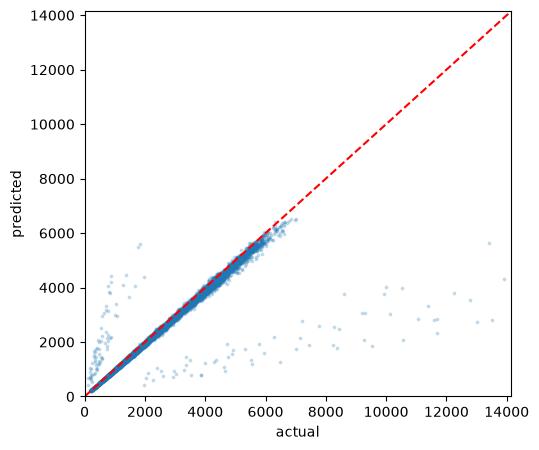

In [19]:
# Where does the error come from? (last fold, final blend)
A = T[T.date < '2025-09-01']; B = T[T.date >= '2025-09-01']
a, b = fr.fill(A, A, 'grouped_median'), fr.fill(B, A, 'grouped_median')
b = b.assign(pred=fr.BlendModel(best_w).fit(a, a.posted_rate).predict(b))
b['ape'] = (b.pred - b.posted_rate).abs() / b.posted_rate * 100
print('median abs % error :', round(b.ape.median(), 2))
print('mean abs % error   :', round(b.ape.mean(), 2))
print('share of loads with error > 25% :', round((b.ape > 25).mean() * 100, 2), '%')
print(b.groupby('equipment').ape.mean().round(2).to_dict())
fig, ax = plt.subplots(figsize=(5.5, 5)); ax.scatter(b.posted_rate, b.pred, s=3, alpha=.2)
lim = [0, b.posted_rate.quantile(.999)]; ax.plot(lim, lim, 'r--'); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('actual'); ax.set_ylabel('predicted'); plt.show()

The typical (median) error is small, but about 1.5% of loads have extreme rates far from any prediction (the stray dots in the plot). They drive the mean error and the RMSE.

## 6. Final model and predictions

In [20]:
T2 = fr.fill(T, T, 'grouped_median'); V2 = fr.fill(V, T, 'grouped_median')
model = fr.BlendModel(best_w).fit(T2, T2.posted_rate)

assert (template.load_id.values == va.load_id.values).all()      # template rows are in validation.csv order
out = template.copy(); out['predicted_rate'] = model.predict(V2).round(2)
out.to_csv('../validation_predictions.csv', index=False)
out.describe().T

,count,mean,std,min,25%,50%,75%,max
predicted_rate,12000.0,2326.442079,1344.61593,212.11,1257.8625,1992.355,3315.2575,6630.13


### December chart
`december_chart_inputs.csv` only has the date, but the model needs coordinates, `market_index` and `quote_signal`. The coordinates are copied from other Lexington / Fort Wayne rows, and `market_index` / `quote_signal` use the daily average of the December rows in `validation.csv`. (This is an assumption – it is stated in the report.)

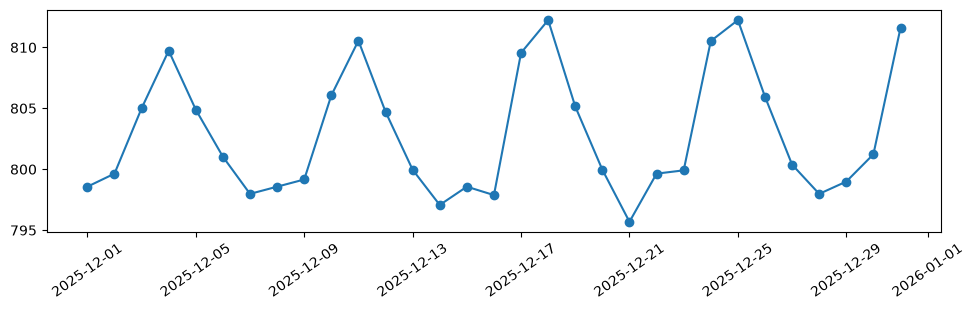

count     31.00
mean     802.92
std        5.16
min      795.69
25%      798.78
50%      800.38
75%      806.00
max      812.24
Name: predicted_rate, dtype: float64

In [22]:
D = fr.fill(fr.prep(fr.build_december_features(dec, tr, va), cats), T, 'grouped_median')
dec['predicted_rate'] = model.predict(D).round(2)
dec.to_csv('E:/task/data/validation-predictions-template.csv', index=False)
plt.figure(figsize=(10, 3.2)); plt.plot(pd.to_datetime(dec.date), dec.predicted_rate, marker='o'); plt.xticks(rotation=35); plt.tight_layout(); plt.show()
dec.predicted_rate.describe().round(2)

## Summary of decisions
| Topic | Decision | Reason |
|---|---|---|
| Split | 3 expanding time folds (last = Sep–Oct) | Test set is the future (Nov–Dec) |
| Target | log(rate) | Skewed; errors behave like percentages |
| Negative weight | `abs()` + flag | Clear sign errors |
| Missing `market_index` | median of the same month | Seasonal |
| Missing `weight` | median of the same equipment | Simple, keeps all rows |
| Loss | absolute error | Squared loss is about 1 point of MAPE worse (extreme rates distort it) |
| Model | 80% gradient boosting + 20% ridge (numpy implementation) | Lowest average error across folds |